In [177]:
import numpy as np
import pandas as pd
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fftshift
import matplotlib.pyplot as plt
import librosa
from scipy.signal import hilbert, butter, lfilter
import os
import textgrid
import sys
import shutil
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import precision_recall_curve

In [178]:
# Generate folds based on individuals

X = np.array(range(1,11))
y = np.ones(X.shape)

skf1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

folds = []

for i, (train_index, test_index) in enumerate(skf1.split(X, y)):
    #print(f"Fold {i}:")
    test = X[test_index]

    shift_add = 5 #random.randint(1,9)
    if test_index[1] == (test_index[0] + shift_add) % 10 or test_index[0] == (test_index[1] + shift_add) % 10:
        shift_add = shift_add + 1

    validate_index = (np.array(test_index) + shift_add) % 10
    validate = X[validate_index]

    train_index = [i for i in train_index if i not in validate_index]
    train = X[train_index]

    check = [x for x in X if x in validate and x in test]


    folds.append(np.concatenate([train, test, validate]))
    assert(len(check)==0)

# Save fold into CSV
folds = np.array(folds)
colums = ["tr"+str(i) for i in range(1,7)]
colums.extend(["v"+str(i) for i in range(1,3)])
colums.extend(["t"+str(i) for i in range(1,3)])

pd.DataFrame(data=folds, columns=colums).to_csv('YellowHammer/Training_set_YH_songs/folds.csv', index=False)

In [179]:
def get_files(folder, id_list):
    files = os.listdir(folder)
    list_files = []
    for id_indiv in id_list:
        yes_files = [f for f in files if "YH_"+str(id_indiv)+"_" in f]
        list_files.extend(yes_files)
    return list_files

In [180]:
folder_data = "YellowHammer/Training_set_YH_songs/clipped/"

df_folds = pd.read_csv('YellowHammer/Training_set_YH_songs/folds.csv')
df_folds = df_folds.to_numpy()

In [181]:
# I got the code from here https://scipy-cookbook.readthedocs.io/items/ButterworthBandpass.html 
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band') # from scipy.signal
    return b, a


def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    #plot_filter(b,a)
    y = lfilter(b, a, data)
    return y

In [182]:
def energy(signal):
    origine = np.sqrt(signal@signal.T/signal.shape[0]) #np.mean(np.abs(signal)) #
    db = librosa.amplitude_to_db(origine)
    return db

In [183]:
def values_db (folder_db,files, exclude_far=False):
    if exclude_far:
        files = [file for file in files if "100m" not in file]
        files = [file for file in files if "150m" not in file]
        files = [file for file in files if "200m" not in file]

    first_clip = []
    second_clip = []
    third_clip = []

    for song_file in files:
        samplerate, data = wavfile.read(folder_db+song_file)
        data = data.astype(float)

        data = butter_bandpass_filter(data, 4000, 9000, samplerate, order=6)
        
        if data.shape[0] >= 1.5*samplerate:
            clip_one = data[0:int(0.5*samplerate)]
            clip_two = data[int(0.5*samplerate):int(1*samplerate)]
            clip_three = data[int(samplerate):int(1.5*samplerate)]

            first_clip.append(energy(clip_one))
            second_clip.append(energy(clip_two))
            third_clip.append(energy(clip_three))
    return first_clip, second_clip, third_clip, np.concatenate([first_clip, second_clip, third_clip])

In [184]:
def predictions_baseline (folder_db,files, df_threshold, exclude_far=False):
    
    if exclude_far:
        files = [file for file in files if "100m" not in file]
        files = [file for file in files if "150m" not in file]
        files = [file for file in files if "200m" not in file]

    first_clip = []
    second_clip = []
    third_clip = []

    for song_file in files:
        samplerate, data = wavfile.read(folder_db+song_file)
        data = data.astype(float)

        data = butter_bandpass_filter(data, 4000, 9000, samplerate, order=6)
        
        if data.shape[0] >= 1.5*samplerate:
            clip_one = data[0:int(0.5*samplerate)]
            clip_two = data[int(0.5*samplerate):int(1*samplerate)]
            clip_three = data[int(samplerate):int(1.5*samplerate)]

            first_clip.append(baseline(clip_one,samplerate, reference=df_threshold))
            second_clip.append(baseline(clip_two,samplerate, reference=df_threshold))
            third_clip.append(baseline(clip_three,samplerate, reference=df_threshold))
    return first_clip, second_clip, third_clip, np.concatenate([first_clip, second_clip, third_clip])

In [185]:
def get_ids (files):
    ids = [f.split("_")[-3] for f in files]
    return np.unique(ids)

In [186]:
def negative_folds(folder_negative):
    files = os.listdir(folder_negative)
    files = [f for f in files if ".wav"]
    y = [0 for f in files]

    X_train, X_test, y_train, y_test = train_test_split(files, y, test_size=0.2, random_state=1)

    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

    return X_train, X_val, X_test

In [187]:
def get_slice(list, start, end):
    return list[int(start*len(list)):int(end*len(list))]

In [188]:
def postive_rate(check):
    if len(check)==0:
        return 0
    return len([b for b in check if b==True])/len(check)

In [189]:
def baseline(signal, srate, reference=40):

    assert signal.shape[0] >= int(srate*0.5)

    filtered_signal = butter_bandpass_filter(signal, 4000, 9000, srate, order=6)
    
    db = energy(filtered_signal)

    return db>=reference

In [190]:
def results (folder, files, threshold, exclude=False):

    first, second, third, all_p = predictions_baseline (folder, files, df_threshold=threshold, exclude_far=exclude)

    PR = np.array([postive_rate(first), postive_rate(second),postive_rate(third)])
    NR = 1 - PR

    pr_all = postive_rate(all_p)
    all_rates = np.array([pr_all, 1-pr_all])

    return np.round(PR,2),np.round(NR,2), np.round(all_rates,2)

### Using simple average

In [192]:
neg_train, neg_val, neg_test = negative_folds('YellowHammer/Training_set_YH_songs/negative_all/')

fld_nb = 0
for fold in df_folds[0:1]:
    fold_train = fold[0:6]
    fold_valid = fold[6:8]
    fold_test = fold[8:10]

    files_train = get_files(folder_data, fold_train)
    files_validate = get_files(folder_data, fold_valid)
    files_test = get_files(folder_data, fold_test)

    start = (fld_nb)/df_folds.shape[0]
    end = (fld_nb+1)/df_folds.shape[0]
    fld_nb = fld_nb + 1

    train_neg_fld = get_slice(neg_train, start,end)
    valid_neg_fld = get_slice(neg_val, start,end)
    test_neg_fld = get_slice(neg_test, start,end)
    
    _, _, _, energy_true = values_db ('YellowHammer/Training_set_YH_songs/clipped/', files_train, exclude_far=False)
    _, _, _, energy_false = values_db ('YellowHammer/Training_set_YH_songs/negative_all/', train_neg_fld, exclude_far=False)
    
    threshold = round((np.quantile(energy_true, 0.25) + np.quantile(energy_false, 0.75))/2, 2)

    print(results ('YellowHammer/Training_set_YH_songs/clipped/', files_test, threshold, exclude=False))
    print(results ('YellowHammer/Training_set_YH_songs/negative_all/', test_neg_fld, threshold, exclude=False))


(array([0.73, 0.81, 0.82]), array([0.27, 0.19, 0.18]), array([0.79, 0.21]))
(array([0.15, 0.09, 0.09]), array([0.85, 0.91, 0.91]), array([0.11, 0.89]))


# Using precision-recall curves

0.8307932786244626 38.1190344999791
Positive: (array([0.71, 0.79, 0.8 ]), array([0.29, 0.21, 0.2 ]), array([0.77, 0.23]))
Negative: (array([0.11, 0.07, 0.05]), array([0.89, 0.93, 0.95]), array([0.08, 0.92]))


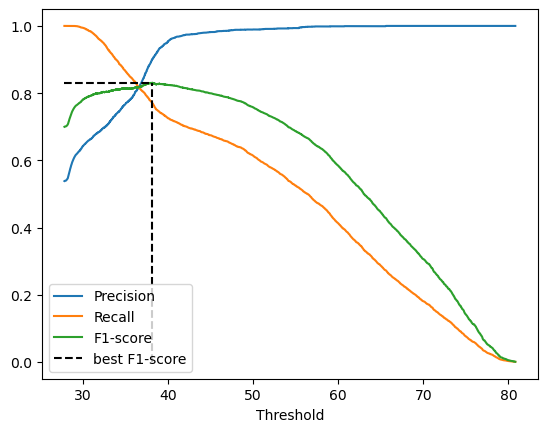

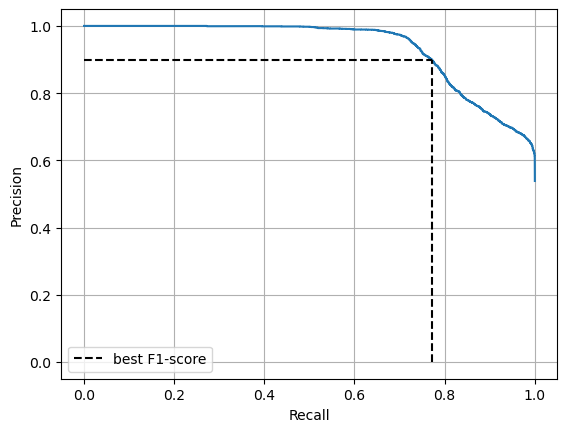

0.8347324896629494 38.806652948852765
Positive: (array([0.79, 0.85, 0.81]), array([0.21, 0.15, 0.19]), array([0.81, 0.19]))
Negative: (array([0.07, 0.02, 0.04]), array([0.93, 0.98, 0.96]), array([0.05, 0.95]))


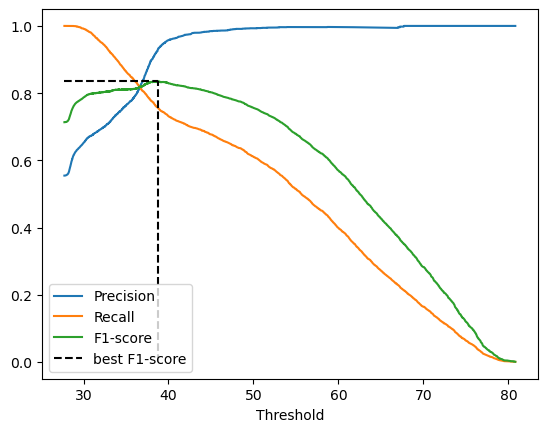

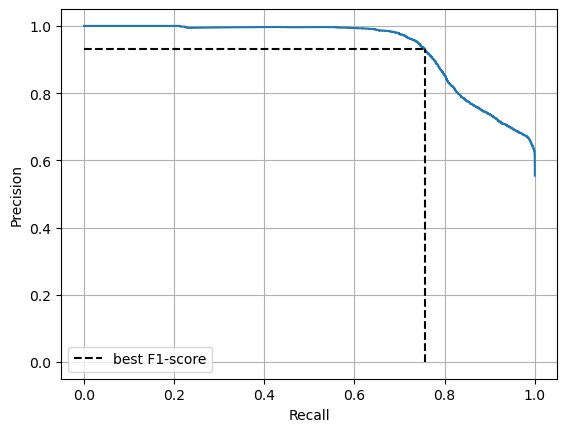

0.8372448979591836 38.70925883558274
Positive: (array([0.73, 0.78, 0.75]), array([0.27, 0.22, 0.25]), array([0.75, 0.25]))
Negative: (array([0.06, 0.05, 0.05]), array([0.94, 0.95, 0.95]), array([0.05, 0.95]))


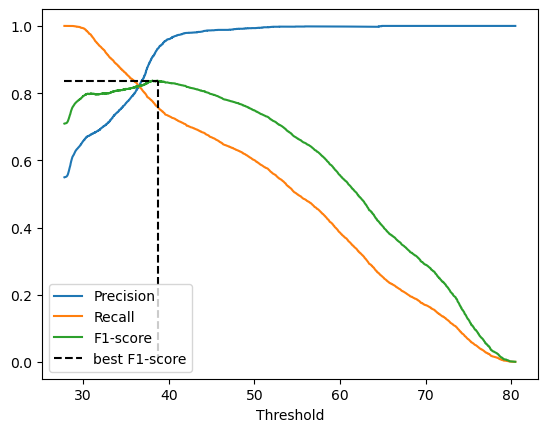

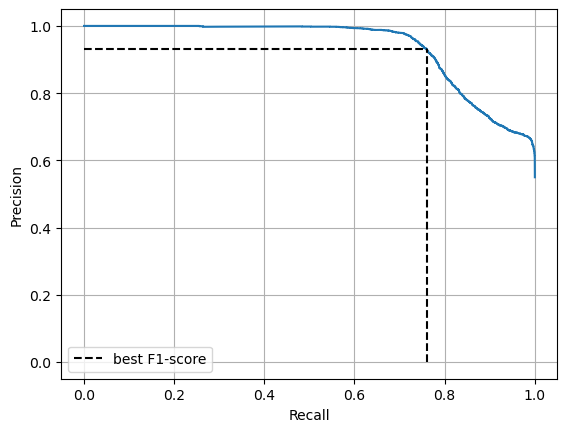

0.8375239310784939 38.71229143418891
Positive: (array([0.71, 0.77, 0.76]), array([0.29, 0.23, 0.24]), array([0.75, 0.25]))
Negative: (array([0.06, 0.04, 0.06]), array([0.94, 0.96, 0.94]), array([0.05, 0.95]))


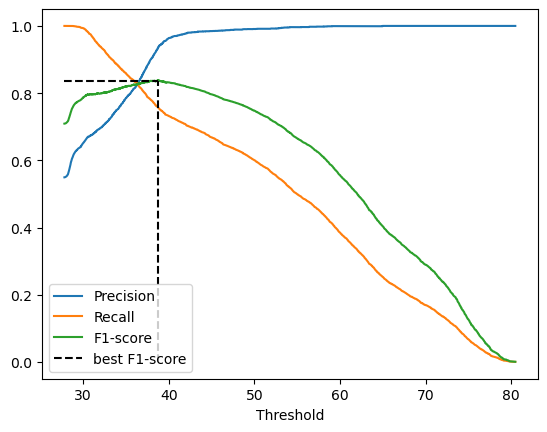

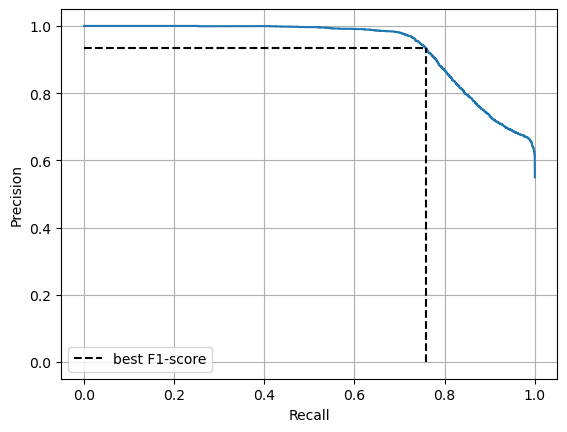

0.8346605479821838 38.728823323235815
Positive: (array([0.67, 0.73, 0.73]), array([0.33, 0.27, 0.27]), array([0.71, 0.29]))
Negative: (array([0.07, 0.05, 0.06]), array([0.93, 0.95, 0.94]), array([0.06, 0.94]))


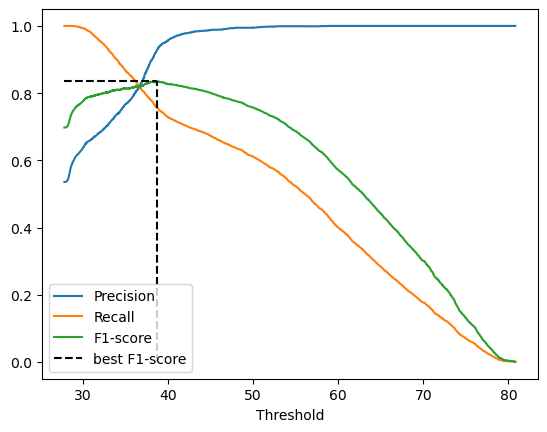

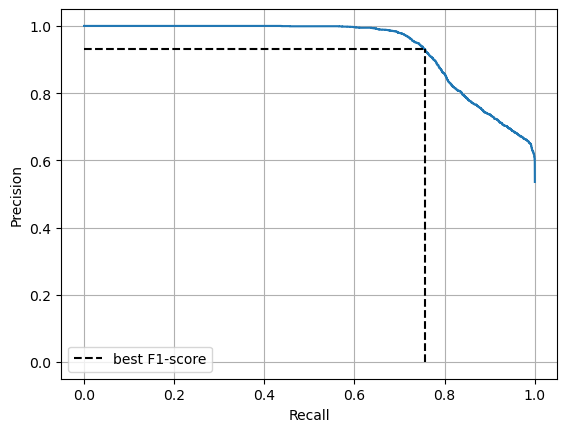

In [ ]:
neg_train, neg_val, neg_test = negative_folds('YellowHammer/Training_set_YH_songs/negative_all/')

fld_nb = 0
for fold in df_folds:
    fold_train = fold[0:6]
    fold_valid = fold[6:8]
    fold_test = fold[8:10]

    files_train = get_files(folder_data, fold_train)
    files_validate = get_files(folder_data, fold_valid)
    files_test = get_files(folder_data, fold_test)

    start = (fld_nb)/df_folds.shape[0]
    end = (fld_nb+1)/df_folds.shape[0]
    fld_nb = fld_nb + 1

    train_neg_fld = get_slice(neg_train, start,end)
    valid_neg_fld = get_slice(neg_val, start,end)
    test_neg_fld = get_slice(neg_test, start,end)
    
    _, _, _, energy_true = values_db ('YellowHammer/Training_set_YH_songs/clipped/', files_train, exclude_far=False)
    _, _, _, energy_false = values_db ('YellowHammer/Training_set_YH_songs/negative_all/', train_neg_fld, exclude_far=False)
    
    
    y_true = np.concatenate([[1 for e in energy_true], [0 for e in energy_false]])
    y_scores = np.concatenate([energy_true, energy_false])

    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_score = 2*precision*recall/(precision+recall)

    print(f1_score[np.argmax(f1_score)], thresholds[np.argmax(f1_score)])

    threshold = thresholds[np.argmax(f1_score)]    
    print("Positive:", results ('YellowHammer/Training_set_YH_songs/clipped/', files_test, threshold, exclude=False))
    print("Negative:", results ('YellowHammer/Training_set_YH_songs/negative_all/', test_neg_fld, threshold, exclude=False))

    if True:
        plt.plot(thresholds, precision[:-1], label="Precision")
        plt.plot(thresholds, recall[:-1], label="Recall")
        plt.plot(thresholds, f1_score[:-1], label="F1-score")
        plt.vlines(threshold, ymin=0, ymax=np.max(f1_score), colors="black", linestyle='--', label="best F1-score")
        plt.hlines(np.max(f1_score), xmin=np.min(thresholds), xmax=threshold, colors="black", linestyle='--')
        plt.xlabel("Threshold")
        plt.legend()
        plt.show()

        # second 
        plt.plot(recall[:-1], precision[:-1])
        plt.vlines(recall[np.argmax(f1_score)], ymin=0, ymax=precision[np.argmax(f1_score)], colors="black", linestyle='--', label="best F1-score")
        plt.hlines(precision[np.argmax(f1_score)], xmin=0, xmax=recall[np.argmax(f1_score)], colors="black", linestyle='--')
        plt.legend()
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(True)
        plt.show()